# Gemma 4: Feature Detection on Satellite Imagery

**Goal:** Test whether Gemma 4 can identify hydraulic and geomorphic features on **satellite (NAIP) imagery** instead of DEM-only renderings.

**Context:** In attempt1, Gemma 4 produced excellent qualitative descriptions on DEM hillshade but had no spatial grounding. With satellite imagery (which is in-distribution for these models), we expect significantly better feature recognition.

**Roadmap reference:** Stage 6.1 — Gemma 4 on Satellite

## Tasks
1. Load satellite RGB image (NAIP, 0.6m resolution)
2. Run general survey prompt on satellite
3. Run targeted prompts: channel, floodplain, ridges, roads, vegetation boundaries
4. Compare quality to attempt1 (DEM hillshade) results
5. Save timestamped outputs to `data/output/model-outputs/attempt2/gemma4/`

In [1]:
import os
import base64
import io
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from openai import OpenAI

# Paths
SATELLITE_PATH = Path("../../data/output/cimarron_satellite.png")
HILLSHADE_PATH = Path("../../data/output/cimarron_hillshade.png")
OUTPUT_DIR = Path("../../data/output/model-outputs/attempt2/gemma4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Timestamp for this run
RUN_TS = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

print(f"Satellite image: {SATELLITE_PATH}")
print(f"Hillshade image: {HILLSHADE_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Run timestamp: {RUN_TS}")

Satellite image: ../../data/output/cimarron_satellite.png
Hillshade image: ../../data/output/cimarron_hillshade.png
Output directory: ../../data/output/model-outputs/attempt2/gemma4
Run timestamp: 2026-04-09_13-07-52


## 1.1 Connect to Gemma 4 via OpenRouter

In [2]:
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY", "")
if not OPENROUTER_API_KEY:
    raise ValueError(
        "Set OPENROUTER_API_KEY in your .env file or environment.\n"
        "Get a free key at: https://openrouter.ai/keys"
    )

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

MODEL = "google/gemma-4-26b-a4b-it"

test = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "Say hello in one word."}],
    max_tokens=10,
)
print(f"OpenRouter connection OK: {test.choices[0].message.content}")
print(f"Model: {MODEL}")

OpenRouter connection OK: Hello.
Model: google/gemma-4-26b-a4b-it


## 1.2 Load Images

Satellite image: (9010, 5313) (RGB)
Hillshade image: (5306, 3088) (RGB)


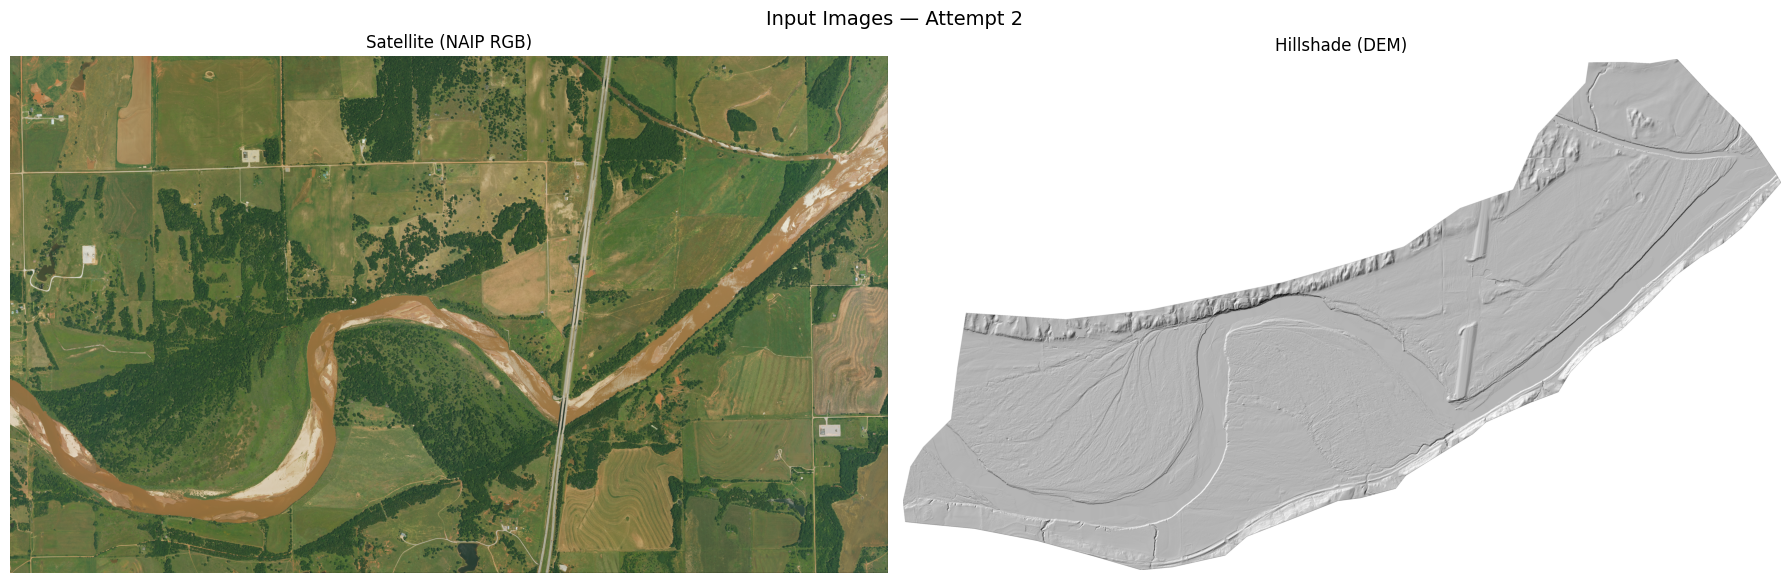

Saved: ../../data/output/model-outputs/attempt2/gemma4/2026-04-09_13-07-52_input_comparison.png


In [3]:
# Load satellite image
if not SATELLITE_PATH.exists():
    raise FileNotFoundError(
        f"Satellite image not found at {SATELLITE_PATH}.\n"
        "Run the satellite acquisition notebook (Stage 5) first."
    )

img_satellite = Image.open(SATELLITE_PATH)
print(f"Satellite image: {img_satellite.size} ({img_satellite.mode})")

# Load hillshade for comparison
img_hillshade = None
if HILLSHADE_PATH.exists():
    img_hillshade = Image.open(HILLSHADE_PATH)
    print(f"Hillshade image: {img_hillshade.size} ({img_hillshade.mode})")

# Side-by-side preview
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(img_satellite)
axes[0].set_title("Satellite (NAIP RGB)")
axes[0].axis("off")
if img_hillshade:
    axes[1].imshow(img_hillshade, cmap="gray")
    axes[1].set_title("Hillshade (DEM)")
    axes[1].axis("off")
plt.suptitle("Input Images — Attempt 2", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{RUN_TS}_input_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR / f'{RUN_TS}_input_comparison.png'}")

## 1.3 Inference Utilities

In [4]:
def resize_for_api(img, max_width=1024):
    """Resize image to reduce API token usage while preserving aspect ratio."""
    if img.width > max_width:
        ratio = max_width / img.width
        new_size = (max_width, int(img.height * ratio))
        return img.resize(new_size, Image.LANCZOS)
    return img


def image_to_base64(img):
    """Convert PIL Image to base64 data URL for the API."""
    img = resize_for_api(img)
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{b64}"


def vision_query(image, prompt, max_tokens=1024):
    """Send an image + text prompt to the vision model and return the response."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": image_to_base64(image)}},
                ],
            }
        ],
        max_tokens=max_tokens,
    )
    return response.choices[0].message.content


vision_results = {}
print("Utilities ready.")

Utilities ready.


## 2.1 Satellite — General Survey

In [5]:
satellite_prompts = {
    "general_survey": (
        "This is a high-resolution satellite photo (NAIP, 0.6m/pixel) of a river corridor "
        "in central Oklahoma. Identify all hydraulic and geomorphic features you can see. "
        "For each feature, describe its type, approximate location in the image, and shape. "
        "Look for: river channels, floodplains, terrace edges, ridges, point bars, oxbow lakes, "
        "levees, road embankments, vegetation boundaries, or any other man-made structures."
    ),
    "channel": (
        "This is a satellite photo of a river corridor. Describe the main river channel: "
        "Where is it in the image? How wide is it? Does it meander? "
        "Are there any secondary or abandoned channels visible? "
        "Describe the water color and any visible sediment patterns."
    ),
    "floodplain": (
        "This is a satellite photo of a river corridor. Identify the floodplain areas. "
        "Where are they relative to the main channel? What vegetation types are visible? "
        "Are there differences between the active floodplain and older terraces? "
        "Can you identify any flood scars or overbank deposits?"
    ),
    "infrastructure": (
        "This is a satellite photo of a river corridor. Identify all man-made features: "
        "roads, bridges, embankments, levees, agricultural fields, buildings, fences, "
        "pipelines, or any other infrastructure. Describe their locations and how they "
        "interact with the natural river system."
    ),
    "vegetation": (
        "This is a satellite photo of a river corridor. Describe the vegetation patterns: "
        "Where is riparian forest vs. open grassland vs. agricultural crops? "
        "Do vegetation boundaries correspond to geomorphic features like terrace edges? "
        "Are there any bare soil or sand bar areas?"
    ),
}

for key, prompt in satellite_prompts.items():
    print(f"\n{'='*80}")
    print(f"TEST: satellite_{key}")
    print(f"{'='*80}")

    response = vision_query(img_satellite, prompt)
    vision_results[f"satellite_{key}"] = {
        "prompt": prompt,
        "response": response,
        "input": "satellite",
    }

    print(response)
    print()


TEST: satellite_general_survey


Based on the high-resolution NAIP imagery provided, the following hydraulic and geomorphic features have been identified within this central Oklahoma river corridor:

### **Hydraulic and Fluvial Features**

*   **Active River Channel:** 
    *   **Type:** Meandering river channel.
    *   **Location:** Traversing diagonally from the bottom left to the top right of the image.
    *   **Shape:** Highly sinuous/meandering. The water appears turbid (brownish color), indicating a high sediment load typical of Oklahoma river systems.
*   **Point Bars:**
    *   **Type:** Accretionary depositional feature.
    *   **Location:** On the inner curves of the river bends (e.g., the large white/light-tan area on the inner curve of the bottom-left bend and the inner curve in the center of the image).
    *   **Shape:** Crescent or fan-shaped, composed of light-colored sand or silt.
*   **Cut Banks (Implied):**
    *   **Type:** Erosional feature.
    *   **Location:** On the outer edges of the river

Based on the satellite image provided, here is a description of the river corridor:

**Location and Meandering**
The main river channel enters from the bottom-left corner, meanders broadly through the center of the image in a "S" shape, and exits through the upper-right corner. It is the most prominent feature in the frame, cutting diagonally across the landscape.

**Width and Shape**
The river width is not uniform. It appears widest in the lower-left section and in the large curve toward the center. In other areas, particularly where it passes under the bridge/road in the right-center of the image, the active water channel appears narrower, flanked by wide, dry sandy banks.

**Secondary and Abandoned Channels**
There are no clearly defined oxbow lakes or fully abandoned meanders visible in this specific shot. However, the wide, pale areas flanking the water suggest a very active floodplain where the river frequently shifts its path, leaving behind wide deposits of sediment.

**Water C

Based on the satellite imagery provided, here is an analysis of the river corridor's geomorphology:

### 1. Floodplain Identification and Location
The **floodplain** consists of the relatively flat, low-lying land areas immediately adjacent to the river channel. 
* **Relative Position:** The floodplain wraps around the meandering curves of the main channel. It is most expansive on the outer bends (cut banks) where the river migrates, and narrower on the inner bends (point bars) where sediment is deposited.

### 2. Vegetation Types
Several distinct vegetation patterns are visible:
* **Riparian Forest/Woodland:** Dense, dark green patches follow the immediate path of the river. This is likely composed of moisture-loving trees and shrubs that thrive in the high water table of the active floodplain.
* **Grasslands/Pasture:** The lighter green, smoother-textured areas surrounding the river corridor appear to be managed grasslands or pastures, likely used for agriculture or grazing.
* **Crop

Based on the satellite imagery provided, here is an identification and description of the man-made features and their interaction with the river system:

### 1. Roads and Transportation Infrastructure
*   **Major Road/Highway:** A prominent, straight north-south road runs through the right side of the image. It acts as a linear boundary cutting through several land parcels.
*   **Bridge:** A bridge spans the river where the highway intersects it in the lower-right quadrant. This is a critical point of interaction, as the engineering of the bridge must account for the river's flow and potential seasonal flooding.
*   **Local/Access Roads:** Several smaller, winding white or light-colored lines are visible, particularly on the left side and bottom of the image. These connect various fields and buildings, often following the contours of the land or field boundaries.

### 2. Agricultural Features
*   **Agricultural Fields:** The landscape is dominated by large, geometric parcels of land. S

Based on the satellite image provided, the vegetation and land cover patterns are clearly defined by the river's path and human land management. Here is a breakdown:

### 1. Vegetation Patterns
*   **Riparian Forest:** This is located in the dense, dark green corridors immediately adjacent to the river. The forest follows the winding path of the river, occupying the low-lying areas within the flood zone.
*   **Open Grassland/Pasture:** The lighter green, more uniform areas surrounding the forest represent grasslands or pastures. These make up the majority of the landscape and are likely used for grazing.
*   **Agricultural Crops:** These are identifiable by the geometric, rectangular patterns. There are several large, light-tan or brownish rectangular plots (likely fallow fields or harvested crops) and some areas with distinct linear "row" textures (visible in the bottom right and top left), indicating actively managed cropland.

### 2. Relationship to Geomorphic Features
*   **Terrace

## 3. Results Summary & Save

In [6]:
# Summary table
print(f"{'Test':<35} {'Response Length':>15}  {'First 80 chars'}")
print("-" * 130)
for key, result in vision_results.items():
    resp_len = len(result["response"])
    preview = result["response"][:80].replace("\n", " ")
    print(f"{key:<35} {resp_len:>10} chars  {preview}...")

print(f"\nTotal queries: {len(vision_results)}")
print(f"Model: {MODEL}")

# Save results to markdown
md_lines = [
    f"# Gemma 4 — Satellite Feature Detection Results\n",
    f"\n**Date:** {RUN_TS}\n",
    f"\n**Model:** `{MODEL}` (via OpenRouter)\n",
    f"\n**Input:** Satellite (NAIP RGB, 0.6m/pixel)\n",
    f"\n**Notebook:** `notebooks/attempt2/01_gemma4_satellite.ipynb`\n",
    f"\n**Attempt:** 2 (satellite imagery)\n",
    "\n---\n",
]

for key, result in vision_results.items():
    md_lines.append(f"\n## {key.replace('_', ' ').title()}\n")
    md_lines.append(f"\n**Prompt:** {result['prompt']}\n")
    md_lines.append(f"\n**Response:**\n\n{result['response']}\n")
    md_lines.append("\n---\n")

output_path = OUTPUT_DIR / f"{RUN_TS}_gemma4_satellite_results.md"
with open(output_path, "w") as f:
    f.writelines(md_lines)

print(f"\nResults saved to: {output_path}")

Test                                Response Length  First 80 chars
----------------------------------------------------------------------------------------------------------------------------------
satellite_general_survey                  3623 chars  Based on the high-resolution NAIP imagery provided, the following hydraulic and ...
satellite_channel                         1553 chars  Based on the satellite image provided, here is a description of the river corrid...
satellite_floodplain                      2466 chars  Based on the satellite imagery provided, here is an analysis of the river corrid...
satellite_infrastructure                  2876 chars  Based on the satellite imagery provided, here is an identification and descripti...
satellite_vegetation                      2055 chars  Based on the satellite image provided, the vegetation and land cover patterns ar...

Total queries: 5
Model: google/gemma-4-26b-a4b-it

Results saved to: ../../data/output/model-outputs/attempt2/